# 🚀 Fine-tuning IndoBERT: Valid Scientific Approach

Notebook ini menggunakan metodologi yang benar secara akademis untuk menangani data tidak seimbang:
1. **Split Data Original**: Memisahkan Train (80%) dan Test (20%) dari data asli.
2. **Augmentasi Train-Only**: Melakukan EDA hanya pada data Training agar model tidak melihat variasi data uji saat pelatihan.
3. **Evaluasi Realistis**: Menguji model pada data asli (Test Set) untuk mengukur performa sebenarnya.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

!pip install transformers torch pandas scikit-learn matplotlib seaborn lime shap nltk

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import pandas as pd
import torch
import random
import nltk
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

nltk.download('wordnet')
nltk.download('omw-1.4')

# Config
BASE_PATH = "/content/drive/MyDrive/xai_lime_vs_shap"
DATA_PATH = os.path.join(BASE_PATH, "data/processed/tokopedia_reviews_clean.csv") # DATA ASLI
OUTPUT_DIR = os.path.join(BASE_PATH, "outputs/indobert_finetuned_v2")
FIG_DIR = os.path.join(BASE_PATH, "outputs/figures")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Using device: cuda


## 1. Split Data Original First
Langkah krusial: Kita pisahkan data tes (20%) SEBELUM melakukan augmentasi.

In [8]:
df_orig = pd.read_csv(DATA_PATH)
LABEL_MAP = {"Negatif": 0, "Netral": 1, "Positif": 2}
df_orig['label'] = df_orig['sentiment_label'].map(LABEL_MAP)

# Split 80% Train, 20% Test dari data asli
df_train_orig, df_test = train_test_split(
    df_orig, test_size=0.2, random_state=42, stratify=df_orig['label']
)

print(f"Original Train samples: {len(df_train_orig)}")
print(f"Original Test samples: {len(df_test)}")
print("\nDistribution in Original Train:")
print(df_train_orig['sentiment_label'].value_counts())

Original Train samples: 1247
Original Test samples: 312

Distribution in Original Train:
sentiment_label
Positif    1134
Negatif      63
Netral       50
Name: count, dtype: int64


## 2. Apply EDA only on Train Set
Fungsi EDA sederhana untuk menyeimbangkan Train Set.

In [9]:
def eda_sr(sentence, n=1):
    words = sentence.split()
    if len(words) < 2: return sentence
    new_words = words.copy()
    for _ in range(n):
        idx1, idx2 = random.sample(range(len(words)), 2)
        new_words[idx1], new_words[idx2] = new_words[idx2], new_words[idx1]
    return " ".join(new_words)

def eda_rd(sentence, p=0.1):
    words = sentence.split()
    if len(words) < 2: return sentence
    new_words = [w for w in words if random.random() > p]
    if len(new_words) == 0: return words[random.randint(0, len(words)-1)]
    return " ".join(new_words)

def balance_data_eda(df, target_samples=500):
    balanced_dfs = []
    for label in ["Negatif", "Netral", "Positif"]:
        df_label = df[df['sentiment_label'] == label].copy()
        current_count = len(df_label)
        if current_count < target_samples:
            needed = target_samples - current_count
            aug_samples = []
            for i in range(needed):
                row = df_label.sample(1).iloc[0]
                text = row['review_text_clean']
                # Alternate techniques
                if i % 2 == 0: aug_text = eda_sr(text)
                else: aug_text = eda_rd(text)
                
                aug_row = row.copy()
                aug_row['review_text_clean'] = aug_text
                aug_samples.append(aug_row)
            
            df_label = pd.concat([df_label, pd.DataFrame(aug_samples)], ignore_index=True)
        balanced_dfs.append(df_label)
    return pd.concat(balanced_dfs, ignore_index=True)

print("Balancing Train Set using EDA...")
df_train_balanced = balance_data_eda(df_train_orig, target_samples=500)
print("\nDistribution in Balanced Train:")
print(df_train_balanced['sentiment_label'].value_counts())

Balancing Train Set using EDA...

Distribution in Balanced Train:
sentiment_label
Positif    1134
Negatif     500
Netral      500
Name: count, dtype: int64


## 3. Training & Evaluation

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.3137
Epoch 2 Loss: 0.0228
Epoch 3 Loss: 0.0062

--- FINAL CLASSIFICATION REPORT (VALID METHOD) ---
              precision    recall  f1-score   support

     Negatif       0.71      0.75      0.73        16
      Netral       0.78      0.58      0.67        12
     Positif       0.97      0.98      0.98       284

    accuracy                           0.95       312
   macro avg       0.82      0.77      0.79       312
weighted avg       0.95      0.95      0.95       312



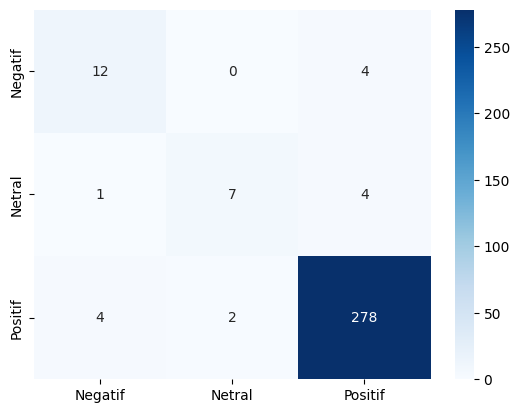

In [10]:
class ReviewDataset(Dataset):
    def __init__(self, reviews, targets, tokenizer, max_len):
        self.reviews = reviews
        self.targets = targets
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self): return len(self.reviews)
    def __getitem__(self, item):
        encoding = self.tokenizer(str(self.reviews[item]), add_special_tokens=True, max_length=self.max_len, padding='max_length', truncation=True, return_tensors='pt')
        return {'input_ids': encoding['input_ids'].flatten(), 'attention_mask': encoding['attention_mask'].flatten(), 'targets': torch.tensor(self.targets[item], dtype=torch.long)}

MODEL_NAME = "indobenchmark/indobert-base-p1"
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
train_loader = DataLoader(ReviewDataset(df_train_balanced.review_text_clean.to_numpy(), df_train_balanced.label.to_numpy(), tokenizer, 128), batch_size=16, shuffle=True)
test_loader = DataLoader(ReviewDataset(df_test.review_text_clean.to_numpy(), df_test.label.to_numpy(), tokenizer, 128), batch_size=16, shuffle=False)

model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3).to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)
loss_fn = torch.nn.CrossEntropyLoss().to(device)

for epoch in range(3):
    model.train()
    total_loss = 0
    for batch in train_loader:
        ids, mask, targets = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['targets'].to(device)
        outputs = model(ids, attention_mask=mask)
        loss = loss_fn(outputs.logits, targets)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")

# Final Evaluation on Original Test Set
model.eval()
y_pred, y_test_real = [], []
with torch.no_grad():
    for batch in test_loader:
        ids, mask, targets = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['targets'].to(device)
        preds = torch.max(model(ids, attention_mask=mask).logits, dim=1)[1]
        y_pred.extend(preds.cpu().numpy())
        y_test_real.extend(targets.cpu().numpy())

print("\n--- FINAL CLASSIFICATION REPORT (VALID METHOD) ---")
print(classification_report(y_test_real, y_pred, target_names=list(LABEL_MAP.keys())))

cm = confusion_matrix(y_test_real, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(LABEL_MAP.keys()), yticklabels=list(LABEL_MAP.keys()))
plt.savefig(os.path.join(FIG_DIR, "fig4_7_confusion_matrix_valid.png"))